# The double-leaves basis and coordinates

`dl(x, y)` is the double-leaves basis of `Hom(BS(x), BS(y))`, graded by degree.
This notebook builds it, then answers the coordinate question in both
directions: given an arbitrary morphism, what are its coordinates, and how do
the two bases of the package translate into each other?

| function | question |
|---|---|
| `dl(x, y)`, `circular_dl(x, y)` | the basis itself, by degree |
| `in_circular_dl_basis(m)` | the coordinates of `m` in the DL basis |
| `cl_basis` + `cl_coordinates` | the coordinates of `m` in the circular-leaf basis |
| `dl_to_circular_matrix` / `circular_to_dl_matrix` | the change of basis, both ways |
| `compose_in_basis`, `structure_constants` | a composite, written in the basis again |

Notebook 10 explains the reduction `DL ↦ CL` all of this sits on.

One practical note used throughout: `DLCombination.coeffs` is a dictionary keyed
by `(degree, index)` with **polynomial** values, so sorting it needs
`sort(collect(c.coeffs); by = first)`. Sorting the pairs themselves compares the
polynomials and raises `Not monomials in comparison`.

In [1]:
using DiagrammaticHecke
debug_labels(true)
debug_circular(true)

true

## 1. The graded table

`dl(x, y)` builds every double leaf once and sorts them by degree. The rank
per degree is compared with the Hecke-algebra pairing (notebook 02).

In [2]:
x = [1, 2, 1]
t = dl(x, x)

DLTable 121 → 121  (12 Double Leaves)
  degree    0   2   4   6
  count     2   5   4   1
  Hecke: matches (basis)


In [3]:
@show dl_degrees(t) dl_ranks(t) expected_ranks(t) ranks_match(t);

dl_degrees(t) = [0, 2, 4, 6]


dl_ranks(t) = [0 => 2, 2 => 5, 4 => 4, 6 => 1]
expected_ranks(t) = [0 => 2, 2 => 5, 4 => 4, 6 => 1]
ranks_match(t) = true


## 2. All double leaves of one degree

`t[d]` is the vector of basis elements of degree `d`; each carries the two
01-sequences `e`, `f`, the common expressed word `z` and the morphism.

degree 2, element 1:  e = [1, 0, 1]  f = [1, 0, 1]  z = Int64[]


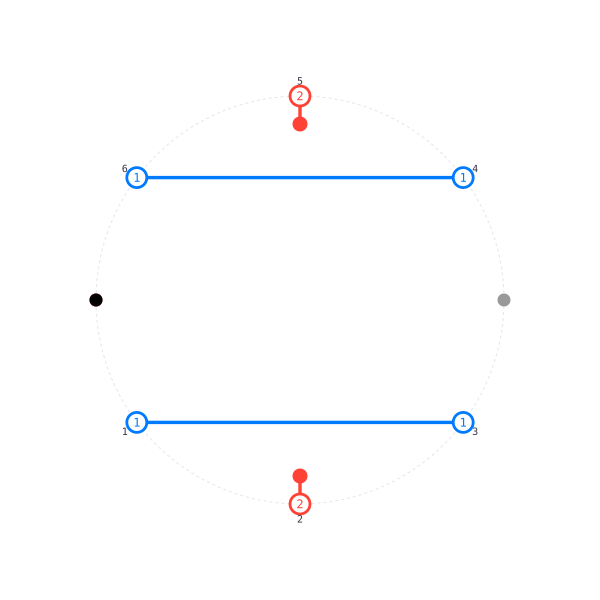

degree 2, element 2:  e = [0, 0, 1]  f = [1, 0, 0]  z = [1]


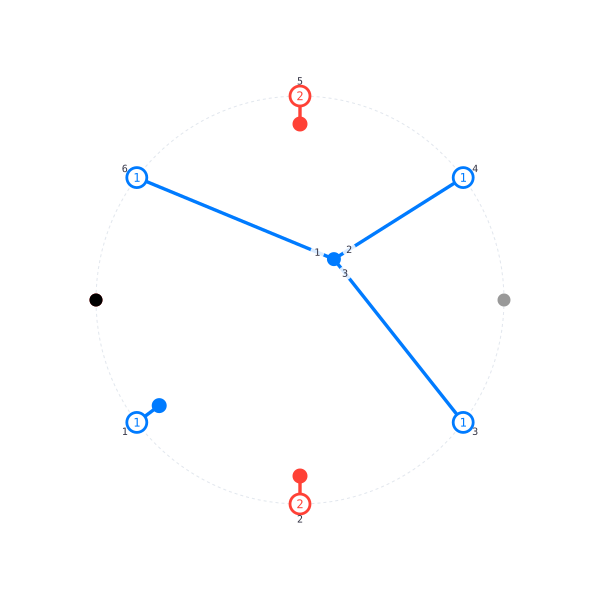

degree 2, element 3:  e = [1, 0, 0]  f = [0, 0, 1]  z = [1]


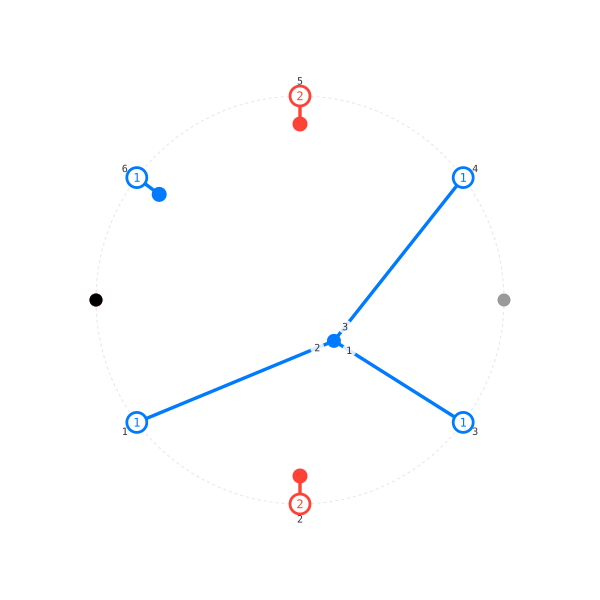

degree 2, element 

4:  e = [1, 1, 0]  f = [1, 1, 0]  z = [1, 2]


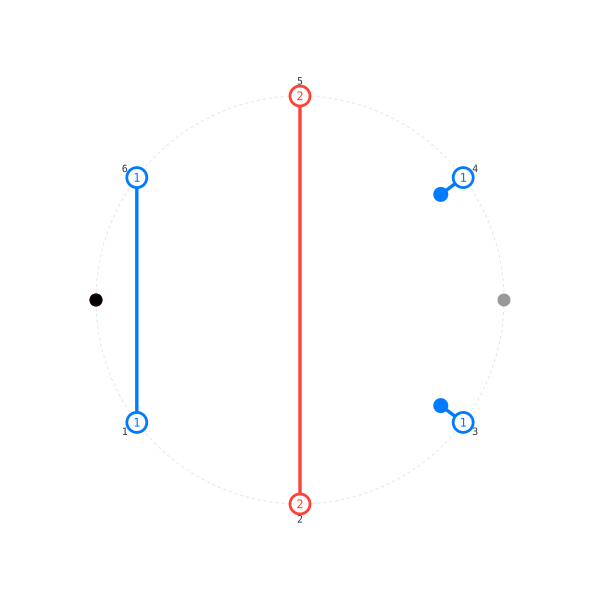

degree 2, element 5:  e = [0, 1, 1]  f = [0, 1, 1]  z = [2, 1]


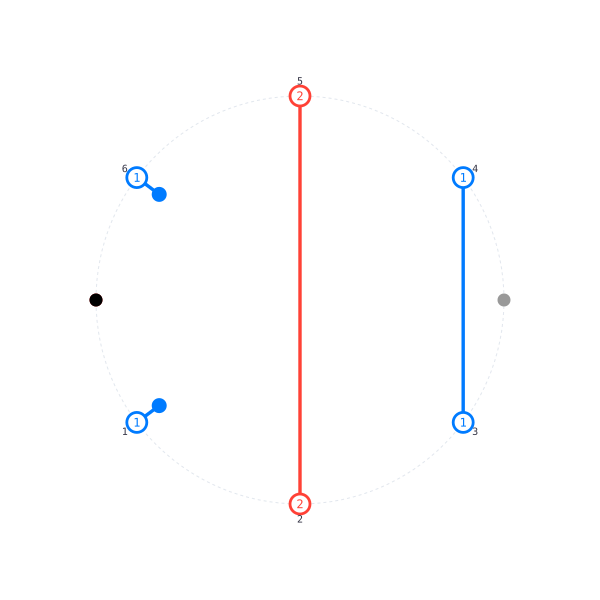

In [4]:
for (j, en) in enumerate(t[2])
    println("degree 2, element ", j, ":  e = ", en.e, "  f = ", en.f, "  z = ", en.z)
    display(en.morphism)
end

## 3. A larger word

For the reduced word `121321` of the longest element the table has 204 double
leaves; the degree-0 part has two elements, the top degree one.

In [5]:
w0 = [1, 2, 1, 3, 2, 1]
t0 = dl(w0, w0)

DLTable 121321 → 121321  (244 Double Leaves)
  degree   -2   0   2   4   6   8  10  12
  count     1  12  44  75  68  34   9   1
  Hecke: matches (basis)


degree 0, element 1:  e = [1, 1, 1, 0, 0, 1]  f = [1, 1, 1, 0, 0, 1]


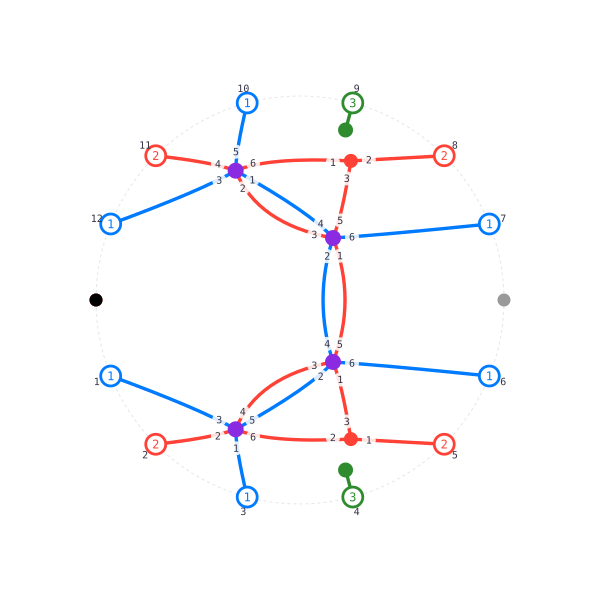

degree 0, element 

2:  e = [0, 1, 1, 0, 1, 0]  f = [1, 1, 1, 0, 0, 0]


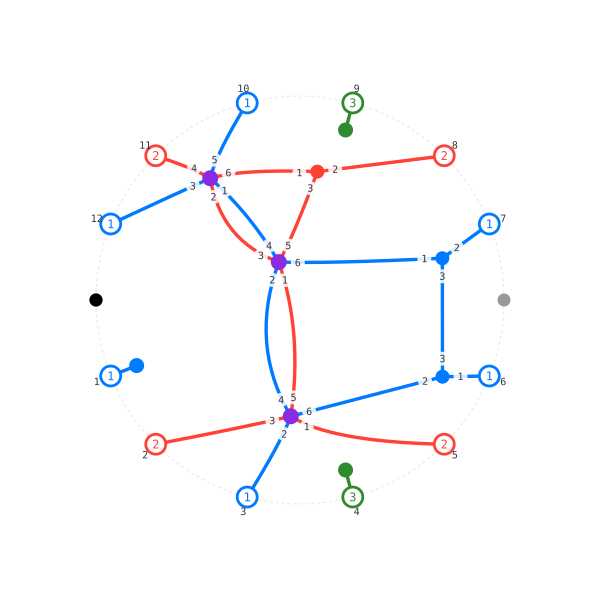

degree 0, element 3:  e = 

[1, 0, 0, 0, 1, 1]  f = [1, 1, 1, 0, 0, 0]


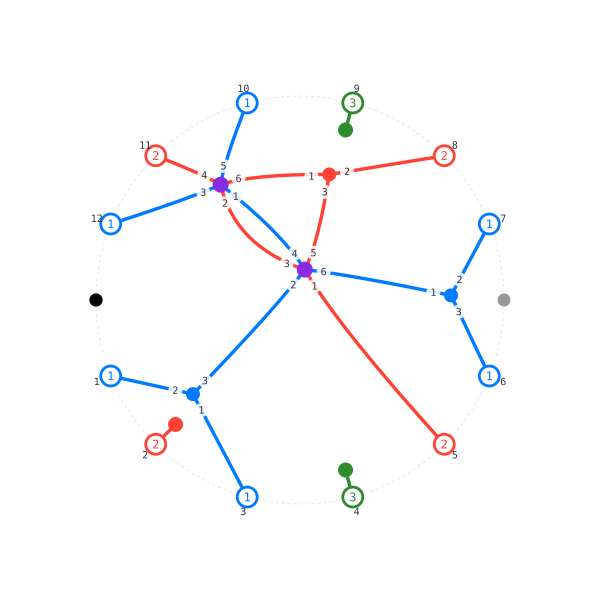

degree 0, element 

4:  e = [1, 1, 0, 0, 0, 1]  f = [1, 1, 1, 0, 0, 0]


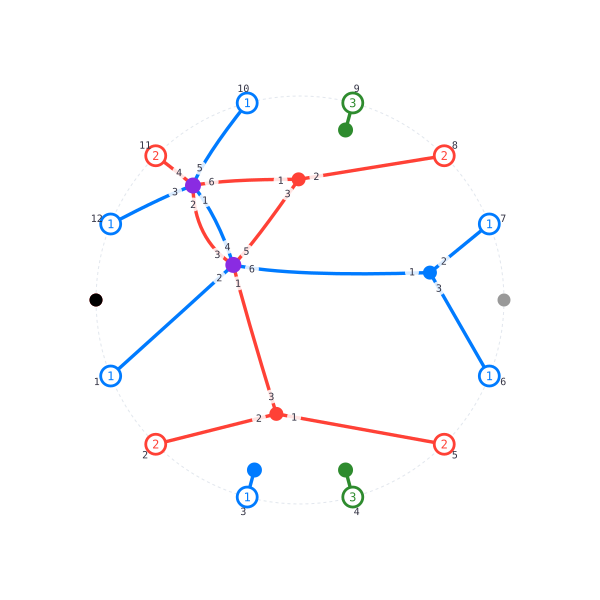

degree 0, element 

5:  e = [1, 1, 1, 0, 0, 0]  f = [0, 1, 1, 0, 1, 0]


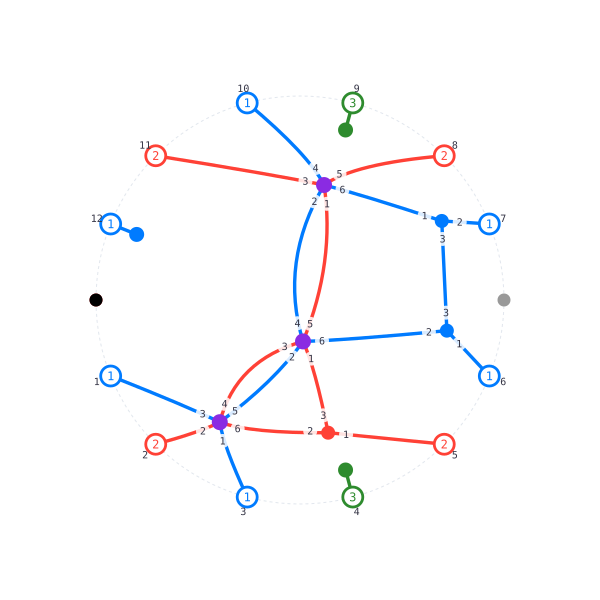

degree 0, element 

6:  e = [1, 1, 1, 0, 0, 0]  f = [1, 0, 0, 0, 1, 1]


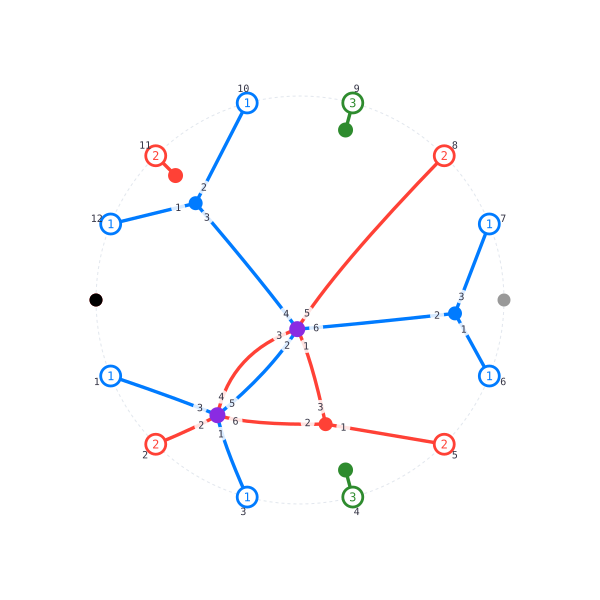

degree 0, element 7:  e = [1, 1, 1, 0, 0, 0]  f = [1, 1, 0, 0, 0, 1]


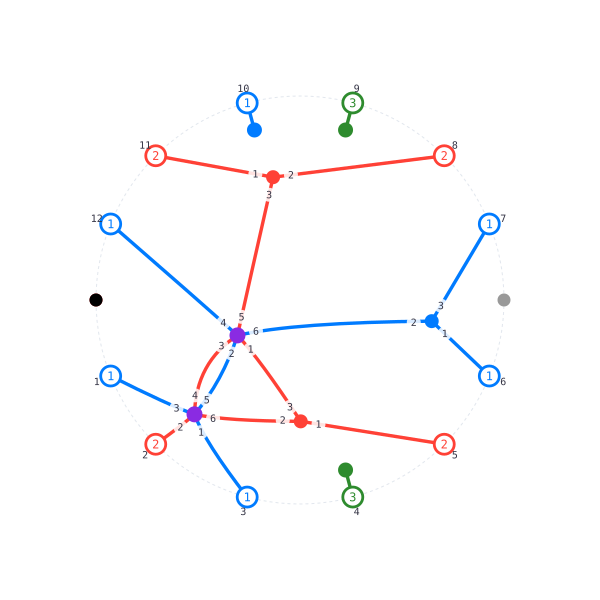

degree 0, element 8:  e = [1, 1, 1, 1, 0, 0]  f = [1, 1, 1, 1, 0, 0]


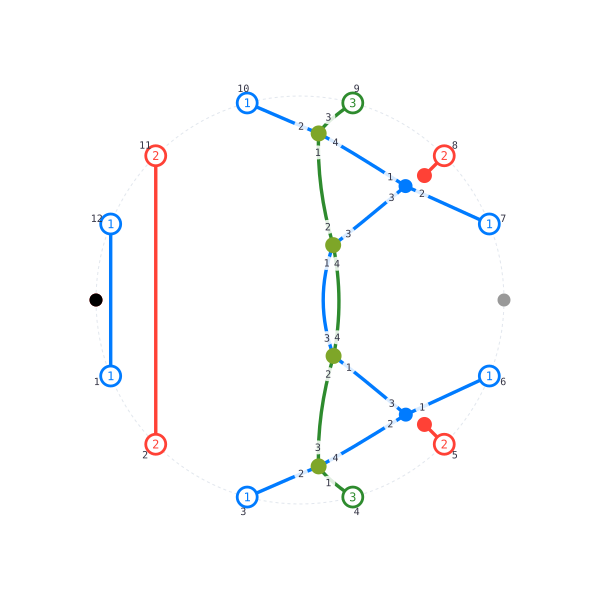

degree 0, element 9:  e = 

[1, 1, 1, 1, 1, 1]  f = [1, 1, 1, 1, 1, 1]


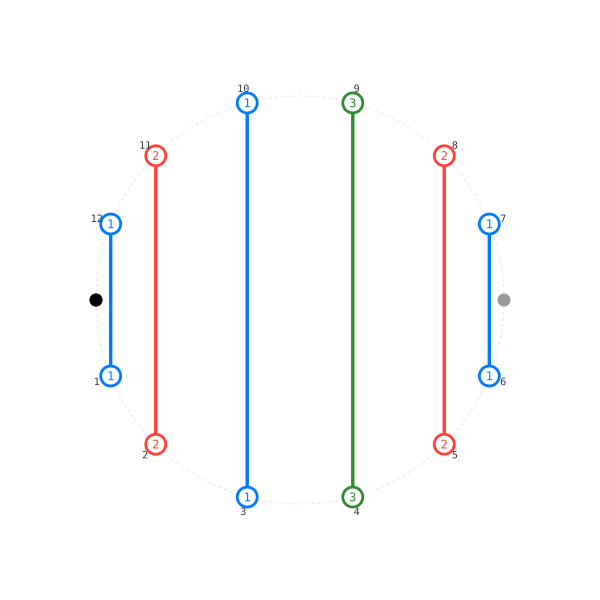

degree 0, element 

10:  e = [1, 0, 0, 1, 0, 0]  f = [1, 0, 0, 1, 0, 0]


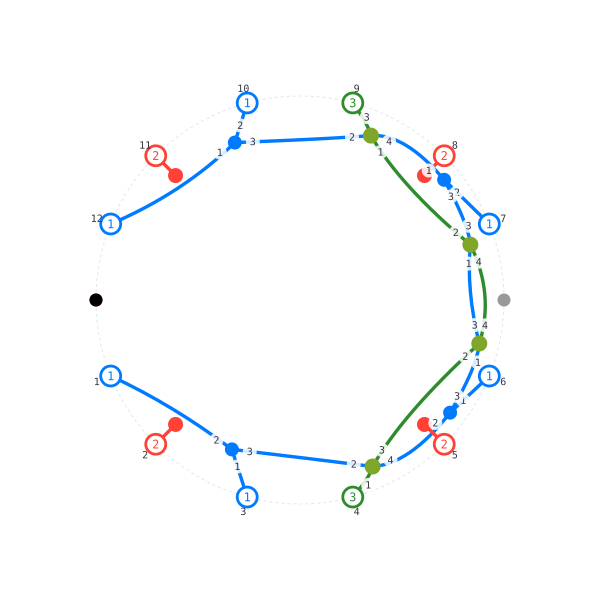

degree 0, element 11:  e = [1, 0, 0, 1, 1, 1]  f = [1, 0, 0, 1, 1, 1]


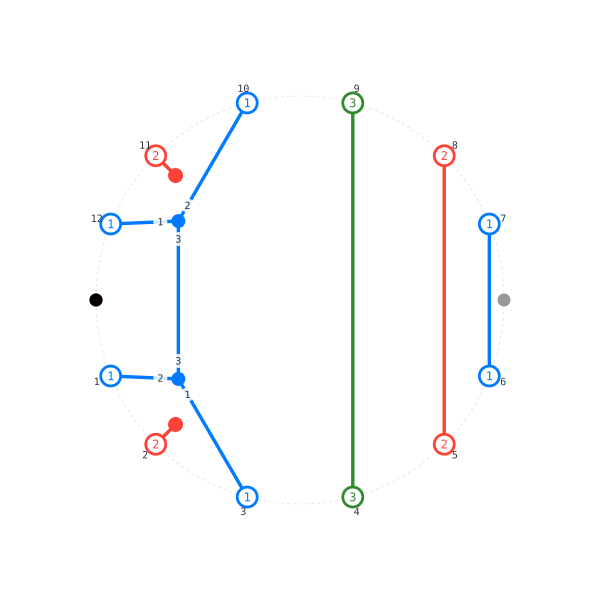

degree 0, element 

12:  e = [1, 1, 1, 0, 1, 0]  f = [1, 1, 1, 0, 1, 0]


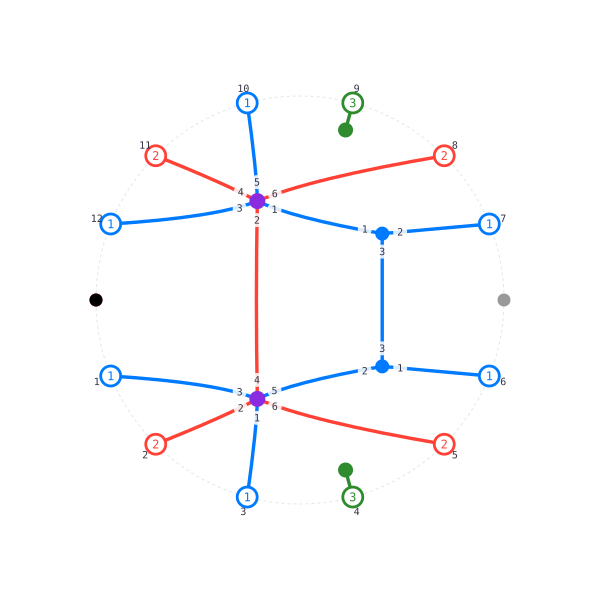

degree 4, element 7:  e = [0, 1, 0, 0, 1, 1]  f = [1, 0, 0, 0, 0, 0]  z = [1]


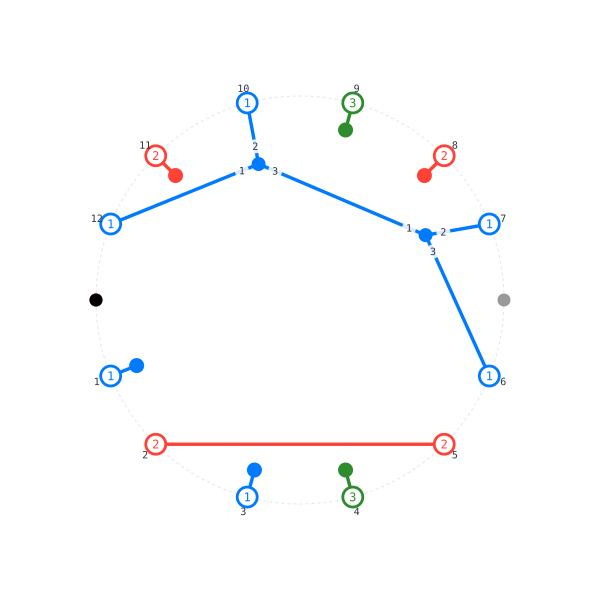

In [6]:
for (j, en) in enumerate(t0[0])
    println("degree 0, element ", j, ":  e = ", en.e, "  f = ", en.f)
    display(en.morphism)
end
en = t0[4][7]
println("degree 4, element 7:  e = ", en.e, "  f = ", en.f, "  z = ", en.z)
display(en.morphism)

## 4. Two different words

In [7]:
t2 = dl([1, 2, 1, 3], [1, 3, 2, 1])

DLTable 1213 → 1321  (20 Double Leaves)
  degree    0   2   4   6   8
  count     1   5   8   5   1
  Hecke: matches (basis)


degree 0, element 1:  e = [1, 0, 0, 1]  f = [1, 1, 0, 0]


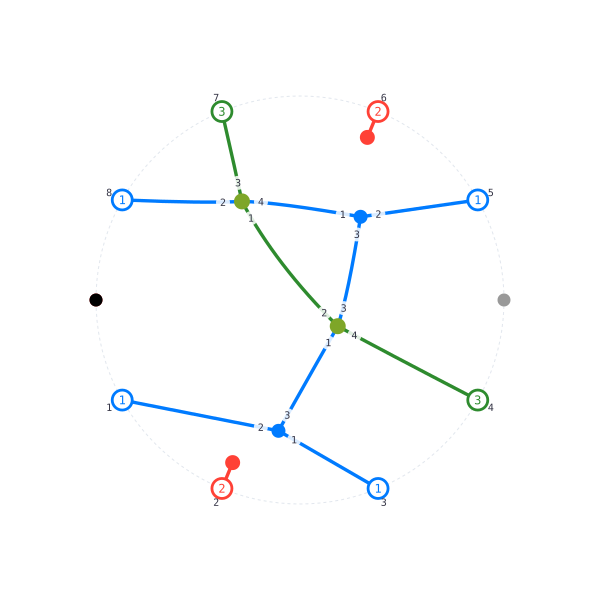

In [8]:
for (j, en) in enumerate(t2[0])
    println("degree 0, element ", j, ":  e = ", en.e, "  f = ", en.f)
    display(en.morphism)
end

## 5. The circular counterparts

`circular_dl(x, y)` reads the same basis as circular morphisms, index-parallel
to `dl(x, y)`.

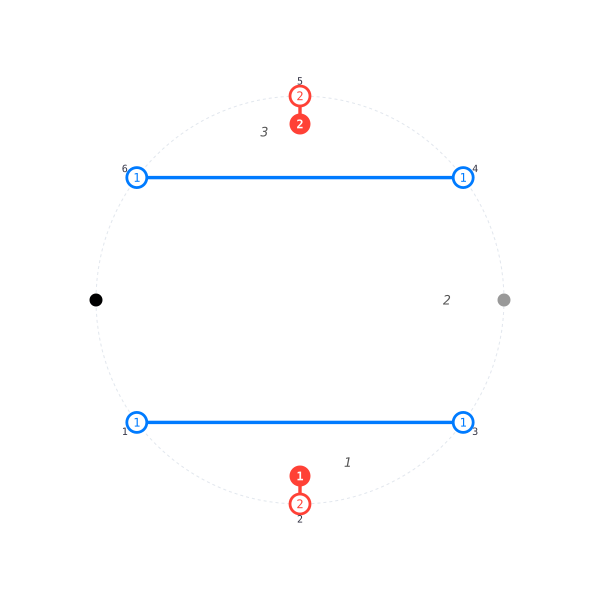

CircularDLTable 121 → 121  (12 Circular Double Leaves)
  degree    0   2   4   6
  count     2   5   4   1
  triangular form: NOT checked (costs a full reduction per Double Leaf) — `is_circular_dl_basis(t)` computes it


In [9]:
ct = circular_dl(x, x)
display(ct[2][1].morphism)
ct

## 6. An arbitrary morphism, not a basis element

Take the word `121` and a morphism that is nobody's basis element: the composite
of the degree-0 double leaf with `dl(x,x)[2][4]`. Most composites of two double
leaves are zero or a single basis element again; this one is neither.

f:  e = [1, 0, 0]  f = [1, 0, 0]  z = [1]


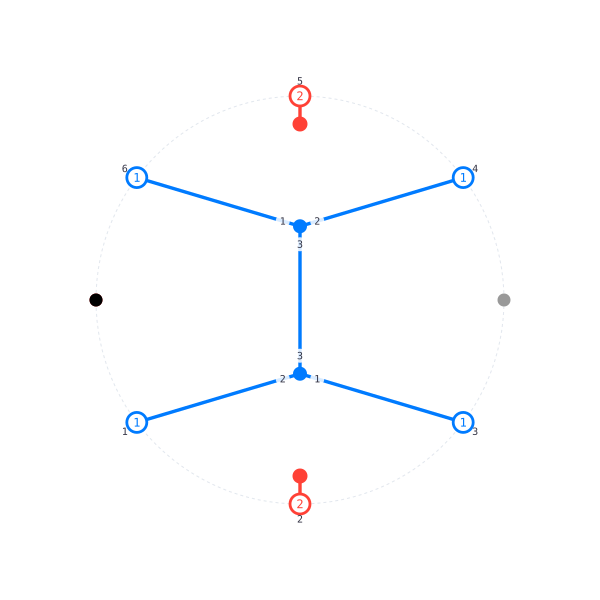

g:  e = [1, 1, 0]  f = [1, 1, 0]  z = [1, 2]


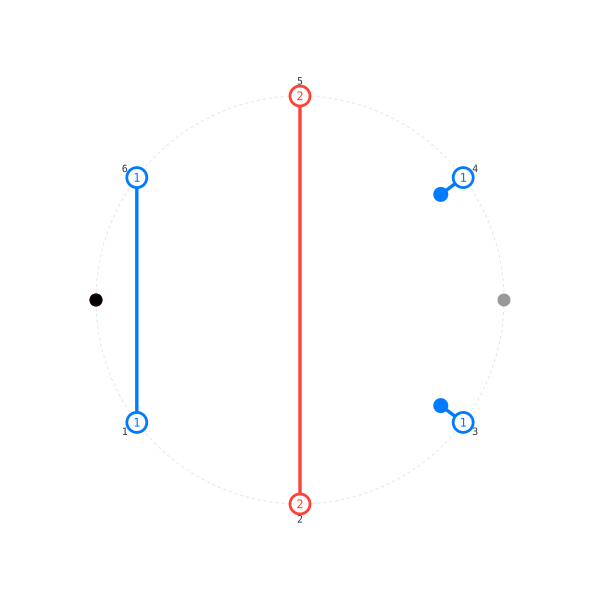

In [10]:
f = t[0][1]                      # degree 0
g = t[2][4]                      # degree 2
println("f:  e = ", f.e, "  f = ", f.f, "  z = ", f.z)
display(f.morphism)
println("g:  e = ", g.e, "  f = ", g.f, "  z = ", g.z)
display(g.morphism)

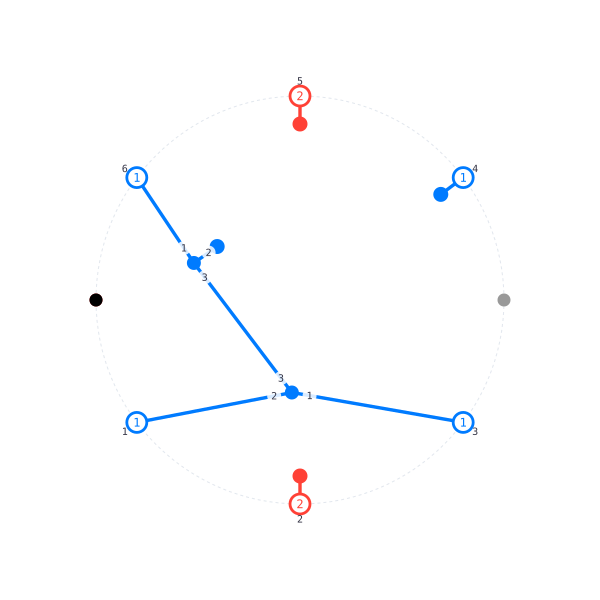

In [11]:
h = compose(f.morphism, g.morphism)     # `compose(f, g)` applies f first: h = g∘f
display(h)

In [12]:
c = in_circular_dl_basis(h)

DLCombination (circular_dl) 121 → 121
  [0][1]  ·  -α₁
  [2][1]  ·  1
  [2][3]  ·  1


Three basis elements, one of them with the coefficient `−α₁²`. That is the
general shape: coordinates live in `R = ℚ[α₁,α₂,α₃]`, not in ℚ.

In [13]:
for (k, v) in sort(collect(c.coeffs); by = first)
    println("dl(x,x)[", k[1], "][", k[2], "]  ·  ", v)
end
@show c.exact
@show c.rest === nothing ? 0 : length(pairs_of(c.rest))

dl(x,x)[0][1]  ·  -

α₁
dl(x,x)[2][1]  ·  1
dl(x,x)[2][3]  ·  1
c.exact = true
if c.rest === nothing
    0
else
    length(pairs_of(c.rest))
end = 0


0

Two fields say how much to trust the answer: `rest` holds the terms that matched
no basis element, and `exact` is `true` only when `rest` is empty **and** the
linear system solved uniquely. A `false` there is a finding about the basis, not
a crash — the combination is still returned so one can look at it.

Reading the coordinates back: rebuild the combination from the basis elements,
reduce it, and compare with the reduction of `h` itself.

In [14]:
lhs = cl_reduce(h)
rhs = CircularComboR()
for (k, v) in c.coeffs
    global rhs
    rhs = rhs + v * cl_reduce(t[k[1]][k[2]].morphism)
end
println("coordinates reproduce the morphism: ", lhs == rhs)

coordinates reproduce the morphism: true


## 7. The two bases against each other

`dl_to_circular_matrix(x, y)` is the matrix `M` of notebook 10: row `k` is the
double leaf `dl_entries(dl(x,y))[k]`, written in circular leaves.
`circular_to_dl_matrix(x, y)` is its exact inverse over `R`, or `nothing` when
there is none. On every pair in this package it exists: `M` comes out square
and invertible.

In [15]:
Mx = dl_to_circular_matrix(x, x)
Minv = circular_to_dl_matrix(x, x)
println("M is ", size(Mx), ", inverse exists: ", Minv !== nothing)
prod = Mx * Minv
println("M · M⁻¹ = 1 over R: ",
        all(prod[i, j] == (i == j ? one(SoergelPoly) : zero(SoergelPoly))
            for i in axes(prod, 1), j in axes(prod, 2)))

M is (12, 12), inverse exists: true


M · M⁻¹ = 1 over R: true


So DL coordinates become CL coordinates by multiplying with `M`, and come back by
multiplying with `M⁻¹`. For `121` the matrix is the identity (notebook 10 §2: the
decomposition is a permutation there), so the two coordinate vectors come out
equal — the round trip below tests the machinery, not a change of numbers.

In [16]:
rows = dl_entries(t)
flat = Dict{Tuple{Int,Int},Int}()
seen = Dict{Int,Int}()
for (k, en) in enumerate(rows)
    j = seen[en.degree] = get(seen, en.degree, 0) + 1
    flat[(en.degree, j)] = k
end
v_dl = fill(zero(SoergelPoly), length(rows))
for (k, val) in c.coeffs
    v_dl[flat[k]] = val
end
println("DL coordinates: ", [(i, string(p)) for (i, p) in enumerate(v_dl) if !iszero(p)])
v_cl = permutedims(v_dl) * Mx
println("CL coordinates: ", [(i, string(p)) for (i, p) in enumerate(v_cl) if !iszero(p)])

DL coordinates: [(1, "-α₁"), (3, "1"), (5, "1")]


CL coordinates: [(1, "-α₁"), (3, "1"), (5, "1")]


In [17]:
back = v_cl * Minv                     # and the way back
println("round trip returns the DL coordinates: ", vec(back) == v_dl)

round trip returns the DL coordinates: true


The CL coordinates computed that way must agree with the ones read straight off
the reduction of `h` — the two ways around the square.

In [18]:
dec = circular_dl_matrix(x, x)
index = Dict(k => i for (i, k) in enumerate(dec.col_key))
direct = fill(zero(SoergelPoly), length(dec.col_key))
for (d, coeff) in pairs_of(cl_reduce(h))
    i = index[circular_canonical_key(d)]
    direct[i] = direct[i] + coeff
end
println("both routes agree: ", vec(v_cl) == direct)

both routes agree: true


The first pair where the change of basis really changes something is `1212`:
there row 17 of `M` has two entries, so a DL coordinate spreads over two circular
leaves, and `M⁻¹` undoes exactly that. (About half a minute — it reduces all 44
double leaves.)

In [19]:
y = [1, 2, 1, 2]
My = dl_to_circular_matrix(y, y)
println("row 17 of M:  ", [(l, string(My[17, l])) for l in axes(My, 2) if !iszero(My[17, l])])
Myinv = circular_to_dl_matrix(y, y)
println("inverse exists: ", Myinv !== nothing)
println("row 17 of M⁻¹: ", [(l, string(Myinv[17, l])) for l in axes(Myinv, 2) if !iszero(Myinv[17, l])])

row 17 of M:  [(17, "1"), (18, "1")]
inverse exists: true
row 17 of M⁻¹: [(18, "1")]


## 8. Composition, expressed in the basis again

`compose_in_basis(f, g)` is section 6 packaged: compose `f: x → y` with
`g: y → z` and write the result over `(x, z)`.

**Argument order.** `compose(f, g)` applies `f` FIRST, so as a product it is the
left multiplication `g∘f`. The argument order and the ∘-notation therefore run
opposite to each other; everything printed below uses the product notation, with
the map applied first on the right.

In [20]:
compose_in_basis(f, g)

DLCombination (circular_dl) 121 → 121
  [0][1]  ·  -α₁
  [2][1]  ·  1
  [2][3]  ·  1


Composing across three different words — `12 → 121 → 12`, so the intermediate
word is genuinely someone else's. Degrees 1 and 3, and the result lands on the
degree-4 basis element with coefficient 1.

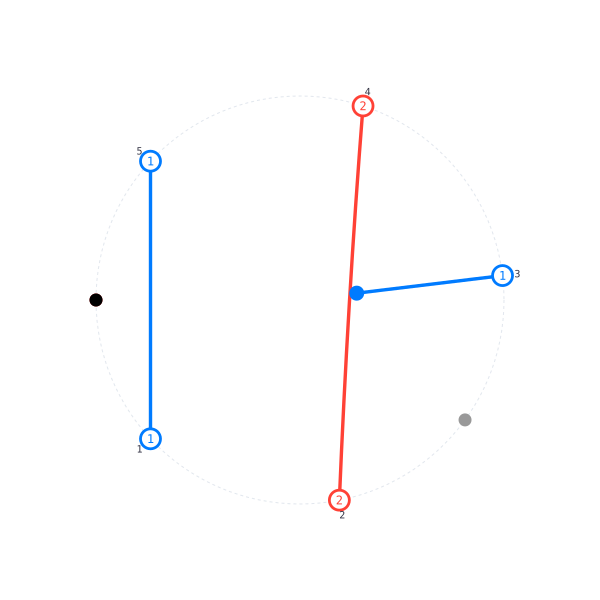

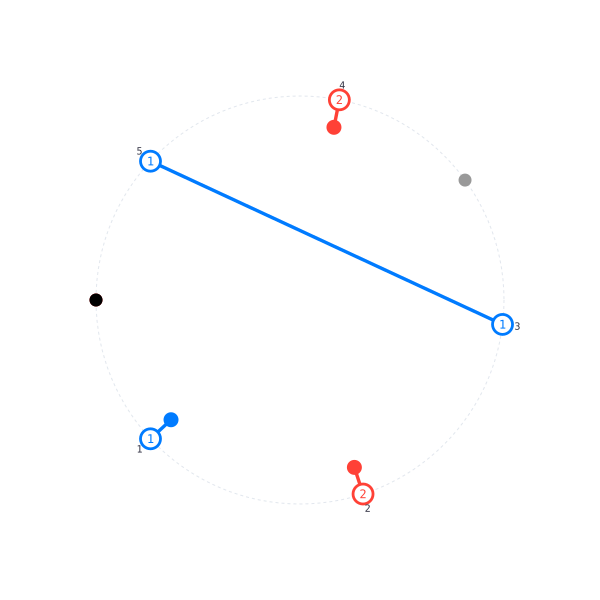

DLCombination (circular_dl) 12 → 12
  [4][1]  ·  1


In [21]:
u, w = [1, 2], [1, 2, 1]
tuw, twu = dl(u, w), dl(w, u)
fu = tuw[1][2]
gw = twu[3][2]
display(fu.morphism)
display(gw.morphism)
cc = compose_in_basis(fu.morphism, gw.morphism)

## 9. The whole multiplication table

`structure_constants(x, y, z)` runs `compose_in_basis` over every pair. It costs
`|dl(x,y)| · |dl(y,z)|` reductions, so it belongs to short words; `12` is small
enough to print in full. Note the polynomial entries `α₁`, `α₂` and `α₁α₂` — the
basis is not closed under composition with constant coefficients.

In [22]:
sc = structure_constants([1, 2], [1, 2], [1, 2])
@show sc.exact length(sc.table) sc.thrown

sc.exact = 

true
length(sc.table) = 16


sc.thrown = Tuple{Tuple{Int64, Int64}, Tuple{Int64, Int64}}[]


Tuple{Tuple{Int64, Int64}, Tuple{Int64, Int64}}[]

In [23]:
# `sc.table` is keyed (f, g) with f applied FIRST. Written as a product it is
# the LEFT multiplication g∘f, so the key is printed in the other order.
for k in sort(collect(keys(sc.table)))
    co = sc.table[k].coeffs
    println("dl", k[2], " ∘ dl", k[1], "  ↦  ",
            isempty(co) ? "0" :
            join([string("dl[", q[1], "][", q[2], "]·", v)
                  for (q, v) in sort(collect(co); by = first)], " + "))
end

dl(0, 1) ∘ dl(0, 1)  ↦  dl[0][1]·1
dl(2, 1) ∘ dl(0, 1)  ↦  dl[2][1]·1
dl(2, 2) ∘ dl(0, 1)  ↦  dl[2][2]·1
dl(4, 1) ∘ dl(0, 1)  ↦  dl[4][1]·1
dl(0, 1) ∘ dl(2, 1)  ↦  dl[2][1]·1
dl(2, 1) ∘ dl(2, 1)  ↦  dl[2][1]·α₂
dl(2, 2) ∘ dl(2, 1)  ↦  dl[4][1]·1
dl(4, 1) ∘ dl(2, 1)  ↦  dl[4][1]·α₂
dl(0, 1) ∘ dl(2, 2)  ↦  dl[2][2]·1
dl(2, 1) ∘ dl(2, 2)  ↦  dl[4][1]·1
dl(2, 2) ∘ dl(2, 2)  ↦  dl[2][2]·α₁
dl(4, 1) ∘ dl(2, 2)  ↦  dl[4][1]·α₁
dl(0, 1) ∘ dl(4, 1)  ↦  dl[4][1]·1
dl(2, 1) ∘ dl(4, 1)  ↦  dl[4][1]·α₂
dl(2, 2) ∘ dl(4, 1)  ↦  dl[4][1]·α₁
dl(4, 1) ∘ dl(4, 1)  ↦  dl[4][1]·α₁*α₂


## 10. The flips

The two mirrors are decomposed the same way. `hflip_dl_matrix(x, y)` writes every
`flip(DL)` in the basis of `(y, x)` and reports whether that is exactly the swap
`(e,f) ↦ (f,e)` — the cellular anti-involution. `vflip_dl_matrix` does the
left-right mirror, which is **not** generally a permutation of the basis.

In [24]:
hf = hflip_dl_matrix([1, 2], [1, 2])
@show hf.exact hf.pure_swap hf.partner;

hf.exact = 

true
hf.pure_swap = true
hf.partner = [1, 2, 3, 4]


In [25]:
vf = vflip_dl_matrix([1, 2, 1], [1, 2, 1])
@show vf.exact vf.permutation;

vf.exact = true
vf.permutation = false


## 11. The same morphism in circular-leaf coordinates

Everything above was the DL basis. `cl_basis` + `cl_coordinates` answer the same
question in the other basis, and `rest` again names what did not fit.

In [26]:
b = cl_basis(x, x)
println(length(b.leaves), " circular leaves, degrees ", b.degrees)
coords = cl_coordinates(cl_reduce(h), b)
println("coefficients: ", [(i, string(p)) for (i, p) in enumerate(coords.coeffs) if !iszero(p)])
println("rest empty:   ", isempty(pairs_of(coords.rest)))

12 circular leaves, degrees [2, 6, 4, 4, 2, 0, 2, 2, 4, 0, 4, 2]
coefficients: 

[(5, "1"), (6, "-α₁"), (7, "1")]
rest empty:   true


In [27]:
# the cross-word composite of section 8, in both bases side by side
println("DL basis:  ", [(k, string(v)) for (k, v) in sort(collect(cc.coeffs); by = first)])
bu = cl_basis(u, u)
cu = cl_coordinates(cl_reduce(compose(fu.morphism, gw.morphism)), bu)
println("CL basis:  ", [(i, string(p)) for (i, p) in enumerate(cu.coeffs) if !iszero(p)])

DL basis:  [((4, 1), "1")]


CL basis:  [(1, "1")]
